In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
acl_df = pd.read_csv("../data/processed/acl_analysis.csv")

In [10]:
acl_df.head()
acl_df.shape
acl_df.info()
acl_df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 430 entries, 0 to 429
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   last_name     430 non-null    str    
 1   first_name    430 non-null    str    
 2   injury        430 non-null    str    
 3   date_ami      430 non-null    str    
 4   level         430 non-null    str    
 5   score_pct     430 non-null    float64
 6   tsk_11        430 non-null    float64
 7   source_sheet  430 non-null    str    
dtypes: float64(2), str(6)
memory usage: 27.0 KB


last_name       0
first_name      0
injury          0
date_ami        0
level           0
score_pct       0
tsk_11          0
source_sheet    0
dtype: int64

In [11]:
analysis_df = acl_df.dropna(subset=["score_pct", "tsk_11"]).copy()
analysis_df.shape

(430, 8)

In [12]:
analysis_df[["score_pct", "tsk_11"]].describe()

,score_pct,tsk_11
count,430.000000,430.000000
mean,73.218605,18.862791
std,10.009256,5.665276
min,35.000000,11.000000
25%,68.000000,16.000000
50%,73.000000,16.000000
75%,79.750000,23.000000
max,98.000000,42.000000


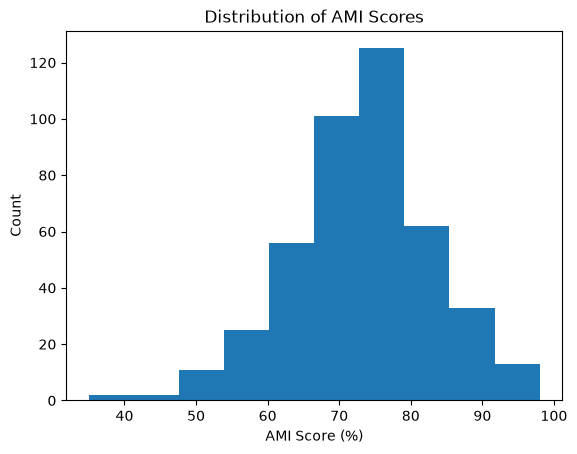

In [13]:
plt.hist(analysis_df["score_pct"])
plt.xlabel("AMI Score (%)")
plt.ylabel("Count")
plt.title("Distribution of AMI Scores")
plt.show()

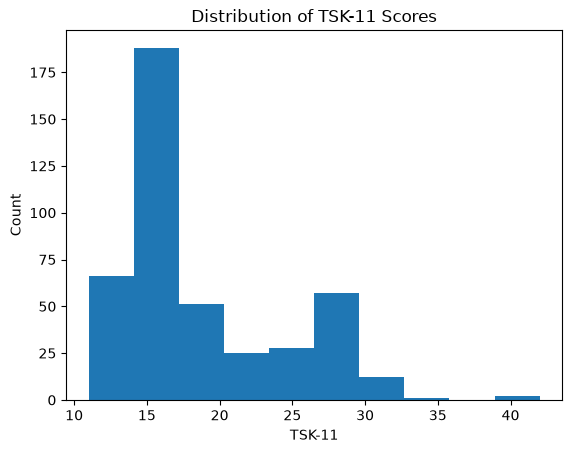

In [14]:
plt.hist(analysis_df["tsk_11"])
plt.xlabel("TSK-11")
plt.ylabel("Count")
plt.title("Distribution of TSK-11 Scores")
plt.show()

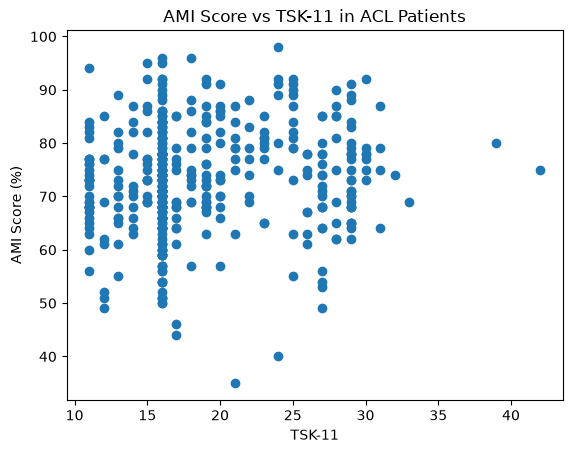

In [15]:
plt.scatter(analysis_df["tsk_11"], analysis_df["score_pct"])
plt.xlabel("TSK-11")
plt.ylabel("AMI Score (%)")
plt.title("AMI Score vs TSK-11 in ACL Patients")
plt.show()

In [16]:
analysis_df[["score_pct", "tsk_11"]].corr()

,score_pct,tsk_11
score_pct,1.000000,0.122742
tsk_11,0.122742,1.000000


In [17]:
from scipy.stats import pearsonr
pearsonr(analysis_df["tsk_11"], analysis_df["score_pct"])

PearsonRResult(statistic=np.float64(0.122742451088584), pvalue=np.float64(0.010850655622742237))